In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit, minimize_scalar
from scipy.signal import find_peaks
import matplotlib.patches as patches
import time
import ast
import pandas as pd
import os

# Functions

In [2]:
def dneff_w(width, a, b):
    '''Function to model the variation of effective index with waveguide width.

    Inputs:
    - width: array of waveguide widths (um)
    - a, b: fitting parameters

    Outputs:
    - dneff: array of effective index variations corresponding to the input widths
    '''
    # Variation of effective index with waveguide width
    width_0 = 1.0
    dneff = a*(width - width_0)**2 + b*(width - width_0)
    return dneff

def neff_wl(wavelength, a, b, c):
    '''Function to model the variation of effective index with wavelength.

    Inputs:
    - wavelength: array of wavelengths (nm)
    - a, b, c: fitting parameters

    Outputs:
    - neff: array of effective indices corresponding to the input wavelengths
    '''
    # Variation of effective index with wavelength
    wl_0 = 1550
    neff = a - b*(wavelength - wl_0) - c*(wavelength - wl_0)**2
    return neff

def neff_model(wavelength_train, width_train, dneff_train, neff_train, width_test, wavelength_test, neff_valid):
    '''Function to model the effective index variation with wavelength and waveguide width.

    Inputs:
    - wavelength_train: array of training wavelengths (nm)
    - width_train: array of training waveguide widths (um)
    - dneff_train: array of training effective index variations
    - neff_train: array of training effective indices
    - width_test: array of test waveguide widths (um)
    - wavelength_test: array of test wavelengths (nm)
    - neff_valid: array of validation effective indices

    Outputs:
    - mse: mean squared error between predicted and validation effective indices
    - neff_test2: array of predicted effective indices for the test data
    - popt_w: optimized parameters for the effective index as a function of waveguide width
    - popt_wl: optimized parameters for the effective index as a function of wavelength
    '''
    width_0 = 1.0
    wl_0 = 1550

    p0_w = [0, 0]
    limits_w = ([-np.inf, -np.inf], [np.inf, np.inf])
    popt_w, pcov_w = curve_fit(dneff_w, width_train, dneff_train, bounds = limits_w, p0=p0_w, maxfev = int(1e5))

    p0_wl = [1.54, 0, 0]
    limits_wl = ([-np.inf, -np.inf, -np.inf], [np.inf, np.inf, np.inf])
    popt_wl, pcov_wl = curve_fit(neff_wl, wavelength_train, neff_train, bounds = limits_wl, p0=p0_wl, maxfev = int(1e5))

    neff_test = neff_wl(wavelength_train, *popt_wl) + dneff_w(width_test, *popt_w)
    mse = np.mean((neff_valid - neff_test)**2)

    neff_test2 = neff_wl(wavelength_test, *popt_wl) + dneff_w(width_test, *popt_w)

    # print(f'neff (λ [nm]) = {popt_wl[0]:.5f} - {popt_wl[1]:.5f}*(λ - {wl_0}) - ({popt_wl[2]:.5e}*(λ - {wl_0})^2)')
    # print(f'Δneff (w [μm]) = {popt_w[0]:.5f}*(w - {width_0})^2 + {popt_w[1]:.5f}*(w - {width_0})')

    return mse, neff_test2, popt_w, popt_wl

def open_file_modesolver(file_path, mode=0):
    ''' Function to open and read mode solver data from a file.

    Inputs:
    - file_path: path to the file containing mode solver data
    - mode: mode number to extract (default is 0, TE0 mode)

    Outputs:
    - wavelength: array of wavelengths
    - n_eff: array of effective indices
    '''
    with open(file_path, 'r') as f:
        first_line = f.readline()

    wl, index, neff = np.loadtxt(file_path, skiprows=1, usecols=(0, 1, 2), dtype=complex, unpack=True)
    filter = (index == mode)
    
    # Load wavelength and effective index
    wavelength, n_eff = wl[filter].real, neff[filter].real

    return wavelength, n_eff

def C_matrix(wavelength, neff, dz):
    '''Function to calculate the propagation matrix for a given wavelength, effective index, and step size.

    Inputs:
    - wavelength: wavelength of light (m)
    - neff: effective index of the waveguide
    - dz: step size along the waveguide (m)
    '''
    C = np.zeros((2, 2), dtype=complex)
    phase = 2*np.pi*neff/wavelength * dz
    C[0,0] = np.exp(1j * phase)
    C[1,1] = np.exp(-1j * phase)
    return C

def I_matrix(neff_1, neff_2):
    '''Function to calculate the interface matrix for two effective indices.
    
    Inputs:
    - neff_1: effective index of the first waveguide section
    - neff_2: effective index of the second waveguide section
    '''
    I = np.zeros((2, 2))
    I[0,0] = neff_1 + neff_2
    I[1,1] = I[0,0]
    I[0,1] = neff_2 - neff_1
    I[1,0] = I[0,1]
    I = (1/(2*np.sqrt(neff_1 * neff_2)))*I
    return I

def Bragg_grating(wavelength, w_array, dz, N, popt_wl, popt_w):
    '''Function to calculate the transfer matrix for a Bragg grating over a range of wavelengths and waveguide widths.

    Inputs:
    - wavelength: array of wavelengths to calculate the transfer matrix for (m)
    - w_array: array of waveguide widths along the grating (m)
    - dz: step size along the grating (m)
    - N: number of steps along the grating
    - popt_wl: optimized parameters for the effective index as a function of wavelength
    - popt_w: optimized parameters for the effective index as a function of waveguide width

    Outputs:
    - M_T: list of transfer matrices for each wavelength
    '''
    M_T = []

    for wl in wavelength:
        M = np.eye(2, dtype=complex)
        neff = []

        for w in w_array:
            n = neff_wl(wl*1e9, *popt_wl) + dneff_w(w, *popt_w)
            neff.append(n)
        
        for i in range(N-1):
            I = I_matrix(neff[i], neff[i+1])
            C = C_matrix(wl, neff[i+1], dz)
            M @= I @ C
        
        M_T.append(M)

    return M_T

def Bragg_grating_mod(wavelength, w_array, dz, N, popt_wl, popt_w, delta_n):
    '''Function to calculate the transfer matrix for a Bragg grating over a range of wavelengths and waveguide widths.

    Inputs:
    - wavelength: array of wavelengths to calculate the transfer matrix for (m)
    - w_array: array of waveguide widths along the grating (m)
    - dz: step size along the grating (m)
    - N: number of steps along the grating
    - popt_wl: optimized parameters for the effective index as a function of wavelength
    - popt_w: optimized parameters for the effective index as a function of waveguide width
    - delta_n: overall experimental refractive index shift

    Outputs:
    - M_T: list of transfer matrices for each wavelength
    '''
    M_T = []

    for wl in wavelength:
        M = np.eye(2, dtype=complex)
        neff = []

        for w in w_array:
            n = neff_wl(wl*1e9, *popt_wl) + dneff_w(w, *popt_w) + delta_n
            neff.append(n)
        
        for i in range(N-1):
            I = I_matrix(neff[i], neff[i+1])
            C = C_matrix(wl, neff[i+1], dz)
            M @= I @ C
        
        M_T.append(M)

    return M_T

def uniform_grating(period, dwidth_2, N, duty, dL):
    '''Function to generate a uniform grating with specified parameters.

    Inputs:
    - period: grating period (m)
    - dwidth_2: corrugation of the second section of the grating (m)
    - N: number of periods in the grating
    - duty: duty cycle of the grating (fraction of the period occupied by the first section)
    - dL: length of the grating (m)

    Outputs:
    - z_real: array of positions along the grating (m)
    - dw_real_p: array of width variations for the positive section of the grating (um)
    - dw_real_n: array of width variations for the negative section of the grating (um)
    '''
    resolution = 500*N # Number of points to represent the grating
    L = period*N
    
    z_real = np.linspace(0, L, resolution)
    dw_real_p = np.where((z_real % period) < (period*duty), 0.0, dwidth_2) # Width variations for the positive section
    dw_real_n = -np.where(((z_real - dL) % period) < (period*duty), 0.0, dwidth_2) # Width variations for the negative section
    return z_real, np.array(dw_real_p), np.array(dw_real_n)

def grating_geometry(z_real, w_real_p, w_real_n, M):
    '''Function to calculate the mean width of the grating in M steps along the z direction.
    
    Inputs:
    - z_real: array of positions along the grating (m)
    - w_real_p: array of width variations for the positive section of the grating (um)
    - w_real_n: array of width variations for the negative section of the grating (um)
    - M: number of steps to divide the grating into
    
    Outputs:
    - z_edges: array of edges of the M steps along the z direction (m)
    - w_mean_p: array of mean widths for the positive section of the grating in each step (um)
    - w_mean_n: array of mean widths for the negative section of the grating in each step (um)
    '''
    # Calculate the mean width of the grating in M steps along the z direction
    L = max(z_real)

    z_edges = np.linspace(0, L, M + 1) 
    w_mean_p = []
    w_mean_n = []
    z_center = []

    for i in range(M):
        z_min = z_edges[i]
        z_max = z_edges[i+1]
        
        mask = (z_real >= z_min) & (z_real < z_max)
        
        step_mean_width_p = np.mean(w_real_p[mask])
        w_mean_p.append(step_mean_width_p)

        step_mean_width_n = np.mean(w_real_n[mask])
        w_mean_n.append(step_mean_width_n)
        
        z_center.append((z_min + z_max) / 2)

    return z_edges, np.array(w_mean_p), np.array(w_mean_n)

def prefab_grating(z_real, sigma, dw_real_p, dw_real_n, scale_factor):
    '''Function to apply a Gaussian filter to the grating width variations and scale by a loss factor.
    
    Inputs:
    - z_real: array of positions along the grating (m)
    - sigma: standard deviation of the Gaussian filter (m)
    - dw_real_p: array of width variations for the positive section of the grating (um)
    - dw_real_n: array of width variations for the negative section of the grating (um)
    - scale_factor: scaling factor to account for losses in the grating
    
    Outputs:
    - dw_fab_p: array of filtered and scaled width variations for the positive section of the grating (um)
    - dw_fab_n: array of filtered and scaled width variations for the negative section of the grating (um)
    '''
    dz = z_real[1] - z_real[0]

    z_kernel = np.arange(-4*sigma, 4*sigma, dz)
    gaussian_kernel = (1/(sigma*np.sqrt(2*np.pi)))*np.exp(-z_kernel**2/(2*sigma**2))
    gaussian_kernel /= np.sum(gaussian_kernel)

    dw_fab_p = np.convolve(dw_real_p, gaussian_kernel, mode='same')
    dw_fab_n = np.convolve(dw_real_n, gaussian_kernel, mode='same')

    dw_fab_p *= scale_factor
    dw_fab_n *= scale_factor

    return dw_fab_p, dw_fab_n

def find_minima(power, wavelength, threshold, separation):
    '''Function to find minima in the power spectrum.

    Inputs:
    - power: array of power values
    - wavelength: array of wavelength values
    - threshold: minimum prominence of the peaks
    - separation: minimum distance between peaks

    Outputs:
    - indices: array of indices of the found minima
    '''
    power_inverted = -power

    # Calculate average step size in wavelength and convert separation from nm to number of points based on average step size
    avg_step = np.mean(np.diff(wavelength)) 
    dist_points = int(separation/avg_step) 

    indices, properties = find_peaks(power_inverted, prominence=threshold, distance=dist_points)

    return indices

def find_minima_sides(wavelength, transmittance, distance):
    idx_min = np.argmin(transmittance)

    left_trans = transmittance[:idx_min]
    left_wl = wavelength[:idx_min]

    left_peaks, _ = find_peaks(left_trans, distance=distance)
    if len(left_peaks) > 0:
        idx_peak_left = left_peaks[-1]
        wl_left = left_wl[idx_peak_left]
        trans_left = left_trans[idx_peak_left]
    else:
        wl_left, trans_left, idx_peak_left = None, None, None

    right_trans = transmittance[idx_min:]

    right_peaks, _ = find_peaks(right_trans, distance=distance)
    if len(right_peaks) > 0:
        idx_peak_right = right_peaks[0] + idx_min
        wl_right = wavelength[idx_peak_right]
        trans_right = transmittance[idx_peak_right]
    else:
        wl_right, trans_right, idx_peak_right = None, None, None

    return [idx_peak_left, idx_peak_right], [wl_left, wl_right]

In [3]:
def open_file(file_path, print_header=False):
    """Function to open OSA data file, extract header information and load wavelength and power data.

    Inputs:
    - file_path: path to the OSA data file
    - print_header: boolean to indicate whether to print header information (default: False)

    Outputs:
    - wavelength: array of wavelength values
    - power: array of power values (adjusted for splitter loss)

    Notes:
    - The function assumes that the splitter header information is in the format "1x2-50/50" (input x output - OSA/OPM) and calculates the
    splitter loss accordingly. If the splitter is "na", it assumes no splitter loss."""

    # Open file
    with open(file_path, 'r') as f:
        first_line = f.readline()

    # Obtain header information 
    header_str = first_line[first_line.find("{"):].strip() 
    header_dict = ast.literal_eval(header_str)
    
    # Print header information
    if print_header:
        print("#"*90)
        print("FILE DATA:")
        print("#"*90)
        for key, value in header_dict.items():
            print(f"{key}: {value}")

    # Calculate splitter loss and adjustment power values
    if header_dict['splitter'] == 'na':
        splitter_opm_loss = 0
        splitter_osa_loss = 0
    
    # For a format like "1x2-50/50" (input x output - OSA/OPM)
    else:
        splitter_loss = header_dict['splitter'].split('-')[-1].split('/')
        splitter_opm_loss = 10*np.log10(float(splitter_loss[1])/100)
        splitter_osa_loss = 10*np.log10(float(splitter_loss[0])/100)

    # Load wavelength and power data
    wavelength, power = np.loadtxt(file_path, comments='%', unpack=True)
    wavelength = wavelength.astype('float')
    power = power.astype('float')

    return wavelength, power - splitter_osa_loss

def filter_wavelength(wavelength, power, wl_0, wl_1):
    """Function to filter wavelength to a desired region.

    Inputs:
    - wavelength: array of wavelength values
    - power: array of power values
    - wl_0: lower bound of the wavelength region
    - wl_1: upper bound of the wavelength region

    Outputs:
    - wavelength: array of filteredwavelength values
    - power: array of filteredpower values"""

    wavelength_filtered = wavelength[(wavelength >= wl_0) & (wavelength < wl_1)]
    power_filtered = power[(wavelength >= wl_0) & (wavelength < wl_1)]
    
    return wavelength_filtered, power_filtered

def find_minima(power, wavelength, threshold, separation):
    '''Function to find minima in the power spectrum.

    Inputs:
    - power: array of power values
    - wavelength: array of wavelength values
    - threshold: minimum prominence of the peaks
    - separation: minimum distance between peaks

    Outputs:
    - indices: array of indices of the found minima
    '''

    power_inverted = -power

    # Calculate average step size in wavelength and convert separation from nm to number of points based on average step size
    avg_step = np.mean(np.diff(wavelength)) 
    dist_points = int(separation/avg_step) 

    indices, properties = find_peaks(power_inverted, prominence=threshold, distance=dist_points)

    return indices

def get_resonance(idx, wavelength_dut, power_dut, power_wg, window_size, fc):
    power_diff = power_dut - power_wg
    power_diff = power_diff - np.max(power_diff)

    indices = find_minima(power_diff, wavelength_dut, threshold, separation)
    wl_min = wavelength_dut[indices]
    power_diff_min = power_diff[indices]

    # Windowing
    wl_0 = wl_min[idx] - window_size/2
    wl_1 = wl_min[idx] + window_size/2
    wavelength_zoom, power_zoom = filter_wavelength(wavelength_dut, power_diff, wl_0, wl_1)

    # Fourier Transform
    step = wavelength_zoom[1] - wavelength_zoom[0]
    fs = 1 / step

    power_zoom_fft = np.fft.fft(10**(power_zoom/10))
    freq = np.fft.fftfreq(len(wavelength_zoom), 1/fs)
    filter = np.abs(freq) < fc
    power_zoom_fft_filtered = power_zoom_fft * filter
    power_zoom_ifft = -10*np.log10(np.abs(np.fft.ifft((power_zoom_fft_filtered))))
    power_zoom_ifft = -power_zoom_ifft
    power_ifft_max = np.max(power_zoom_ifft)

    power_zoom_ifft = power_zoom_ifft - power_ifft_max
    power_zoom = power_zoom - power_ifft_max

    return wavelength_zoom, power_zoom, power_zoom_ifft

In [4]:
def run_tmm_simulation_scale(scale_factor, i, z_real, dw_real_p, dw_real_n, M_fab, 
                       width_0, wl_min_real, window_size, popt_wl, popt_w, delta_n):
    """
    Ejecuta la simulación TMM para un scale_factor dado
    y devuelve la longitud de onda de mínima transmisión simulada (wl_min_pred).
    """

    dw_fab_p, dw_fab_n = prefab_grating(z_real, sigma_0, dw_real_p, dw_real_n, scale_factor)
    z_edges_fab, dw_mean_fab_p, dw_mean_fab_n = grating_geometry(z_real, dw_fab_p, dw_fab_n, M_fab)
    w_mean_fab = dw_mean_fab_p - dw_mean_fab_n + width_0

    wavelength_test = (np.arange(wl_min_real - window_size, wl_min_real + window_size, 0.125)) * 1e-9
    dz = L/ M_fab
    
    M_wl = Bragg_grating_mod(wavelength_test, w_mean_fab, dz, M_fab, popt_wl, popt_w, delta_n)

    T_fab = np.zeros(len(wavelength_test))
    for j in range(len(wavelength_test)):
        T_fab[j] = 1 / (np.abs(M_wl[j][0, 0])**2)

    T_fab_dB = 10 * np.log10(T_fab)
    min_T_dB = np.min(T_fab_dB)

    idx_min = np.argmin(T_fab)
    wl_min_pred = wavelength_test[idx_min]
    
    return min_T_dB, wl_min_pred, T_fab, wavelength_test

# Objective class
class ScaleOptimizationTracker:
    def __init__(self, power_min_ifft, wl_min_ifft, i, z_real, dw_real_p, dw_real_n, M_fab, 
                 width_0, wl_min_real, window_size, popt_wl, popt_w, delta_n):
        self.power_min_ifft = power_min_ifft
        self.wl_min_ifft = wl_min_ifft
        self.i = i
        self.z_real = z_real
        self.dw_real_p = dw_real_p
        self.dw_real_n = dw_real_n
        self.M_fab = M_fab
        self.width_0 = width_0
        self.wl_min_real = wl_min_real
        self.window_size = window_size
        self.popt_wl = popt_wl
        self.popt_w = popt_w
        self.delta_n = delta_n
        
        self.iteration = 0

    def __call__(self, sf_candidate):
        self.iteration += 1
        t0 = time.perf_counter()

        min_T_dB, wl_min_pred, _, _ = run_tmm_simulation_scale(
            scale_factor=sf_candidate,
            i=self.i,
            z_real=self.z_real,
            dw_real_p=self.dw_real_p,
            dw_real_n=self.dw_real_n,
            M_fab=self.M_fab,
            width_0=self.width_0,
            wl_min_real=self.wl_min_real,
            window_size=self.window_size,
            popt_wl=self.popt_wl,
            popt_w=self.popt_w,
            delta_n=self.delta_n
        )
        
        # Control parameter
        d_T = self.power_min_ifft - min_T_dB
        d_wl = self.wl_min_ifft*1e-9 - wl_min_pred
        error_sq = d_wl**2

        t1 = time.perf_counter()
        elapsed_time = t1 - t0

        print(f"Iteration {self.iteration:2d} | "
              f"Scale Factor (γ): {sf_candidate:.5f} | "
              f"Δλ: {d_wl * 1e9:6.5f} nm | "
              f"ΔT: {d_T:6.5f} dB | "
              f"Time: {elapsed_time:.3f} s")

        return error_sq

def run_tmm_simulation_sigma(sigma_candidate, scale_factor, i, z_real, dw_real_p, dw_real_n, 
                             M_fab, width_0, wl_min_real, window_size, popt_wl, popt_w, delta_n):
    """
    Ejecuta la simulación TMM evaluando un valor específico de sigma
    y obtiene el valor mínimo de transmisión en dB.
    """

    dw_fab_p, dw_fab_n = prefab_grating(z_real, sigma_candidate, dw_real_p, dw_real_n, scale_factor)
    z_edges_fab, dw_mean_fab_p, dw_mean_fab_n = grating_geometry(z_real, dw_fab_p, dw_fab_n, M_fab)
    w_mean_fab = dw_mean_fab_p - dw_mean_fab_n + width_0

    wavelength_test = (np.arange(wl_min_real - window_size, wl_min_real + window_size, 0.125)) * 1e-9
    dz = L/M_fab
    
    M_wl = Bragg_grating_mod(wavelength_test, w_mean_fab, dz, M_fab, popt_wl, popt_w, delta_n)

    T_fab = np.zeros(len(wavelength_test))
    for j in range(len(wavelength_test)):
        T_fab[j] = 1 / (np.abs(M_wl[j][0, 0])**2)

    T_fab_dB = 10 * np.log10(T_fab)
    min_T_dB = np.min(T_fab_dB)

    idx_min = np.argmin(T_fab)
    wl_min_pred = wavelength_test[idx_min]
    
    return min_T_dB, wl_min_pred, T_fab_dB, wavelength_test

# Objective class
class SigmaOptimizationTracker:
    def __init__(self, power_min_ifft, wl_min_ifft, scale_factor, i, z_real, dw_real_p, dw_real_n, 
                 M_fab, width_0, wl_min_real, window_size, popt_wl, popt_w, delta_n):
        self.power_min_ifft = power_min_ifft
        self.wl_min_ifft = wl_min_ifft
        self.scale_factor = scale_factor
        self.i = i
        self.z_real = z_real
        self.dw_real_p = dw_real_p
        self.dw_real_n = dw_real_n
        self.M_fab = M_fab
        self.width_0 = width_0
        self.wl_min_real = wl_min_real
        self.window_size = window_size
        self.popt_wl = popt_wl
        self.popt_w = popt_w
        self.delta_n = delta_n
        
        self.iteration = 0

    def __call__(self, sigma_candidate):
        self.iteration += 1
        t0 = time.perf_counter()

        min_T_dB, wl_min_pred,  _, _ = run_tmm_simulation_sigma(
            sigma_candidate=sigma_candidate,
            scale_factor=self.scale_factor,
            i=self.i,
            z_real=self.z_real,
            dw_real_p=self.dw_real_p,
            dw_real_n=self.dw_real_n,
            M_fab=self.M_fab,
            width_0=self.width_0,
            wl_min_real=self.wl_min_real,
            window_size=self.window_size,
            popt_wl=self.popt_wl,
            popt_w=self.popt_w,
            delta_n=self.delta_n
        )

        # Control parameter
        d_T = self.power_min_ifft - min_T_dB
        d_wl = self.wl_min_ifft*1e-9 - wl_min_pred
        error_sq = d_T**2

        t1 = time.perf_counter()
        elapsed_time = t1 - t0

        print(f"Iteration {self.iteration:2d} | "
              f"σ: {sigma_candidate * 1e9:6.3f} nm | "
              f"ΔT: {d_T:6.5f} dB | "
              f"Δλ: {d_wl*1e9:6.5f} nm | "
              f"Time: {elapsed_time:.3f} s")

        return error_sq

# Initialization

In [5]:
material = 'BCB'
wl_center = 1550

# U1 design parameters
N_u1 = 1000
wl_u1 = (np.arange(8)-3)*10 + wl_center

# U2 design parameters
N_u2 = 2000
wl_u2 = (np.arange(6)-2)*10 + wl_center

# U3 design parameters
N_u3 = 4000
wl_u3 = (np.arange(4)-2)*10 + wl_center

width_0 = 1.0 # Nominal Width of the waveguide (um)
width = np.round(width_0 + np.arange(0, 9)*0.05, 2) # Waveguide width list (um)
dwidth = (width - width_0)/2 # Corrugation list (um)

In [6]:
equipment = 'YOKO'
gratings = 'uniform'

# Laser range
d_wl = 4
wl_0 = 1530 - d_wl 
wl_1 = 1600 + d_wl

n_eff = 1.5743

# U1 design parameters
dW_u1 = (np.arange(8)+1)*50

period_u1 = wl_u1/(2*n_eff)*1e-9
L_u1 = N_u1*period_u1

# U2 design parameters
dW_u2 = (np.arange(6)+1)*50

period_u2 = wl_u2/(2*n_eff)*1e-9
L_u2 = N_u2*period_u2

# U3 design parameters
dW_u3 = (np.arange(4)+2)*50

period_u3 = wl_u3/(2*n_eff)*1e-9
L_u3 = N_u3*period_u3

## Design

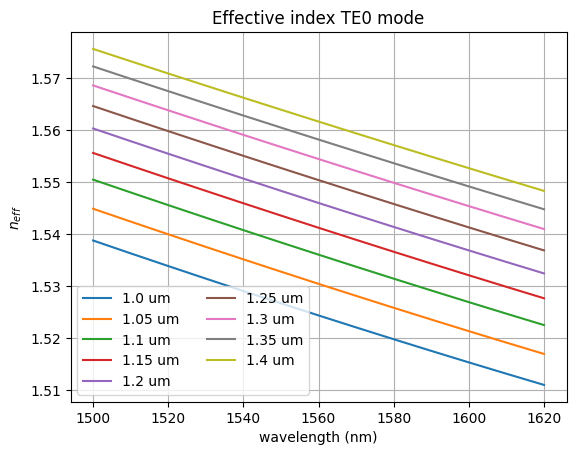

In [7]:
# Extract Effective Indices from Modesolver results
dneff = []
n_eff = []

file_path = f"/home/arjoa/UPVfab/upvfab-design-tools/results/{material}/1.0um/modesolver_results_1.0um.txt"
wavelength_0, neff_0 = open_file_modesolver(file_path)

for w in width:
    file_path = f"/home/arjoa/UPVfab/upvfab-design-tools/results/{material}/{w}um/modesolver_results_{w}um.txt"
    wavelength, neff = open_file_modesolver(file_path)

    dneff.append(np.mean(neff - neff_0))
    n_eff.append(neff)
    plt.plot(wavelength, neff, label=f'{w} um')

plt.title('Effective index TE0 mode')
plt.xlabel('wavelength (nm)')
plt.ylabel(r'$n_{eff}$')
plt.grid()
plt.legend(ncols=2)
plt.show()

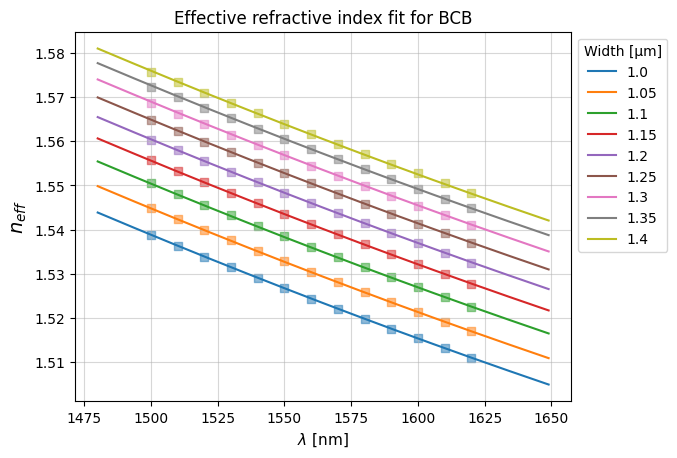

In [8]:
# Create and effective index model for the waveguides as a funcion of wavelength and width
dneff_train = dneff
neff_train = n_eff[0]
wavelength_train = wavelength
width_train = width

wavelength_test = np.arange(1480, 1650, 1)

for i, w in enumerate(width):
    width_test = w
    neff_valid = n_eff[i]

    mse, neff_test, popt_w, popt_wl = neff_model(wavelength_train, width_train, dneff_train, neff_train, width_test, wavelength_test, neff_valid)

    fit, = plt.plot(wavelength_test, neff_test, label = f'{width_test}')
    plt.scatter(wavelength, neff_valid, color = fit.get_color(), alpha=0.5, marker='s')
    
plt.title(fr'Effective refractive index fit for {material}')
plt.xlabel(r'$\lambda$ [nm]', fontsize=11)
plt.ylabel(r'$n_{eff}$', fontsize=14)
plt.grid(which='both', alpha=0.5)
plt.legend(fontsize = 10, title='Width [μm]', bbox_to_anchor=(1, 1), loc='upper left')
plt.show()

U1 parameters 

λ   = [1520 1530 1540 1550 1560 1570 1580 1590] (nm)
ΔW  = [ 25.  50.  75. 100. 125. 150. 175. 200.] (nm)
Λ   = [494.5100947  497.64142118 500.82363834 504.05772417 507.34468885
 510.68557587 514.08146312 517.53346404] (nm)


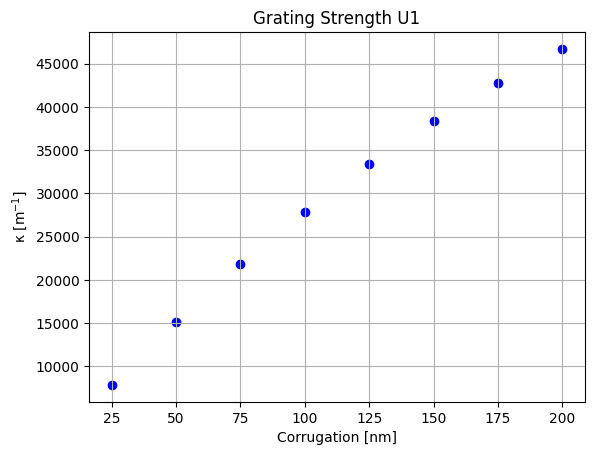

In [9]:
# Obtain the grating period for each U1 Bragg grating
period_array_u1 = []
n1_array = []
n2_array = []
n_avg_u1 = []

i = 1 # Start with a corrugation of 25 nm
for bragg_wl in wl_u1:
    neff_1 = neff_wl(bragg_wl, *popt_wl) + dneff_w(width_0, *popt_w)
    neff_2 = neff_wl(bragg_wl, *popt_wl) + dneff_w(width[i], *popt_w)

    n_avg = (neff_1 + neff_2)/2
    period = bragg_wl/(2*n_avg)

    n1_array.append(float(neff_1))
    n2_array.append(float(neff_2))
    n_avg_u1.append(float(n_avg))
    period_array_u1.append(float(period*1e-3))
    i+=1

print('U1 parameters \n')
print(f'λ   = {wl_u1} (nm)')
print(f'ΔW  = {(width[1:] - width_0)/2*1e3} (nm)')
print(f'Λ   = {np.array(period_array_u1)*1e3} (nm)')

# Grating Strength Estimation
delta_n = np.array(n2_array) - np.array(n1_array)
kappa_u1 = 2*delta_n/((np.array(n1_array)  + np.array(n2_array))*np.array(period_array_u1)*1e-6)
plt.scatter((width[1:] - width_0)/2*1e3, kappa_u1, color='b')

plt.title('Grating Strength U1')
plt.ylabel(r'κ [m$^{-1}$]')
plt.xlabel('Corrugation [nm]')
plt.grid()
plt.show()

U2 parameters 

λ   = [1530 1540 1550 1560 1570 1580] (nm)
ΔW  = [ 25.  50.  75. 100. 125. 150.] (nm)
Λ   = [498.54817136 501.67392744 504.8509589  508.08024049 511.36277939
 514.69961629] (nm)


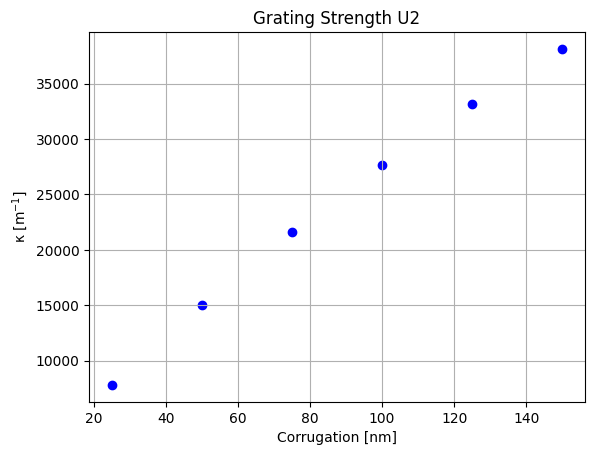

In [10]:
# Obtain the grating period for each U2 Bragg grating
period_array_u2 = []
n1_array = []
n2_array = []
n_avg_u2 = []

i = 1 # Start with a corrugation of 25 nm
for bragg_wl in wl_u2:
    neff_1 = neff_wl(bragg_wl, *popt_wl) + dneff_w(width_0, *popt_w)
    neff_2 = neff_wl(bragg_wl, *popt_wl) + dneff_w(width[i], *popt_w)

    n_avg = (neff_1 + neff_2)/2
    period = bragg_wl/(2*n_avg)

    n1_array.append(float(neff_1))
    n2_array.append(float(neff_2))
    n_avg_u2.append(float(n_avg))
    period_array_u2.append(float(period*1e-3))
    i+=1

print('U2 parameters \n')
print(f'λ   = {wl_u2} (nm)')
print(f'ΔW  = {(width[1:7] - width_0)/2*1e3} (nm)')
print(f'Λ   = {np.array(period_array_u2)*1e3} (nm)')

# Grating Strength
delta_n = np.array(n2_array) - np.array(n1_array)
kappa_u2 = 2*delta_n/(wl_u2*1e-9)
plt.scatter((width[1:7] - width_0)/2*1e3, kappa_u2, color='b')

plt.title('Grating Strength U2')
plt.ylabel(r'κ [m$^{-1}$]')
plt.xlabel('Corrugation [nm]')
plt.grid()
plt.show()

U3 parameters 

λ   = [1530 1540 1550 1560] (nm)
ΔW  = [ 50.  75. 100. 125.] (nm)
Λ   = [497.64142118 500.82363834 504.05772417 507.34468885] (nm)


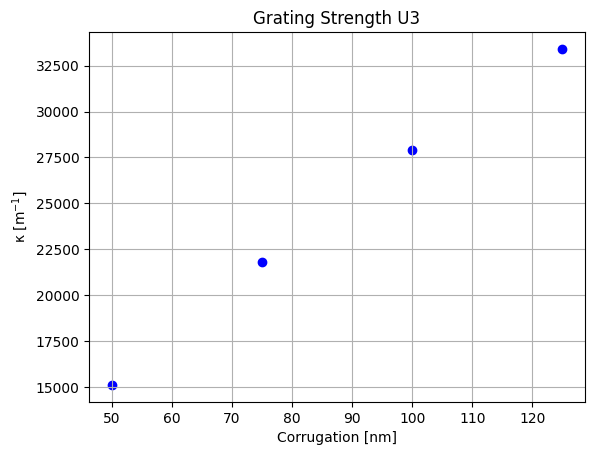

In [11]:
# Obtain the grating period for each U3 Bragg grating
period_array_u3 = []
n1_array = []
n2_array = []
n_avg_u3 = []

i = 2 # Start with a corrugation of 50 nm
for bragg_wl in wl_u3:
    neff_1 = neff_wl(bragg_wl, *popt_wl) + dneff_w(width_0, *popt_w)
    neff_2 = neff_wl(bragg_wl, *popt_wl) + dneff_w(width[i], *popt_w)

    n_avg = (neff_1 + neff_2)/2
    period = bragg_wl/(2*n_avg)

    n1_array.append(float(neff_1))
    n2_array.append(float(neff_2))
    n_avg_u3.append(float(n_avg))
    period_array_u3.append(float(period*1e-3))
    i+=1

print('U3 parameters \n')
print(f'λ   = {wl_u3} (nm)')
print(f'ΔW  = {(width[2:6] - width_0)/2*1e3} (nm)')
print(f'Λ   = {np.array(period_array_u3)*1e3} (nm)')

# Grating Strength
delta_n = np.array(n2_array) - np.array(n1_array)
kappa_u3 = 2*delta_n/(wl_u3*1e-9)
plt.scatter((width[2:6] - width_0)/2*1e3, kappa_u3, color='b')

plt.title('Grating Strength U3')
plt.ylabel(r'κ [m$^{-1}$]')
plt.xlabel('Corrugation [nm]')
plt.grid()
plt.show()

## Characterization

In [12]:
if equipment == 'OSA20' and gratings == 'uniform':
    vs = 2.0 #nm/s (OSA20 sensitivity = 5.0)
    
    ##### Reference Waveguides ##############################################################################
    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4/2/5\wg.txt" 
    wavelength_wg_r2, power_wg_r2 = open_file(file_path)
    wavelength_wg_r2, power_wg_r2 = filter_wavelength(wavelength_wg_r2, power_wg_r2, wl_0, wl_1)

    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4/4/5\wg.txt"   
    wavelength_wg_r4, power_wg_r4 = open_file(file_path)
    wavelength_wg_r4, power_wg_r4 = filter_wavelength(wavelength_wg_r4, power_wg_r4, wl_0, wl_1)

    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4/7/5\wg.txt"   
    wavelength_wg_r7, power_wg_r7 = open_file(file_path)
    wavelength_wg_r7, power_wg_r7 = filter_wavelength(wavelength_wg_r7, power_wg_r7, wl_0, wl_1)

    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4/10/5\wg.txt"  
    wavelength_wg_r10, power_wg_r10 = open_file(file_path)
    wavelength_wg_r10, power_wg_r10 = filter_wavelength(wavelength_wg_r10, power_wg_r10, wl_0, wl_1)

    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4/12/5\wg.txt"  
    wavelength_wg_r12, power_wg_r12 = open_file(file_path)
    wavelength_wg_r12, power_wg_r12 = filter_wavelength(wavelength_wg_r12, power_wg_r12, wl_0, wl_1)

    ##### U1 ################################################################################################
    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4/2/5\u1.txt"   
    wavelength_u1_r2, power_u1_r2 = open_file(file_path)
    wavelength_u1_r2, power_u1_r2 = filter_wavelength(wavelength_u1_r2, power_u1_r2, wl_0, wl_1)

    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4/4/5\u1.txt"   
    wavelength_u1_r4, power_u1_r4 = open_file(file_path)
    wavelength_u1_r4, power_u1_r4 = filter_wavelength(wavelength_u1_r4, power_u1_r4, wl_0, wl_1)

    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4/7/5\u1.txt"   
    wavelength_u1_r7, power_u1_r7 = open_file(file_path)
    wavelength_u1_r7, power_u1_r7 = filter_wavelength(wavelength_u1_r7, power_u1_r7, wl_0, wl_1)

    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4/10/5\u1.txt"  
    wavelength_u1_r10, power_u1_r10 = open_file(file_path)
    wavelength_u1_r10, power_u1_r10 = filter_wavelength(wavelength_u1_r10, power_u1_r10, wl_0, wl_1)

    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4/12/5\u1.txt"   
    wavelength_u1_r12, power_u1_r12 = open_file(file_path)
    wavelength_u1_r12, power_u1_r12 = filter_wavelength(wavelength_u1_r12, power_u1_r12, wl_0, wl_1)

    ##### U2 ################################################################################################
    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4/2/5\u2.txt"   
    wavelength_u2_r2, power_u2_r2 = open_file(file_path)
    wavelength_u2_r2, power_u2_r2 = filter_wavelength(wavelength_u2_r2, power_u2_r2, wl_0, wl_1)

    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4/4/5\u2.txt" 
    wavelength_u2_r4, power_u2_r4 = open_file(file_path)
    wavelength_u2_r4, power_u2_r4 = filter_wavelength(wavelength_u2_r4, power_u2_r4, wl_0, wl_1)

    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4/7/5\u2.txt" 
    wavelength_u2_r7, power_u2_r7 = open_file(file_path)
    wavelength_u2_r7, power_u2_r7 = filter_wavelength(wavelength_u2_r7, power_u2_r7, wl_0, wl_1)

    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4/10/5\u2.txt" 
    wavelength_u2_r10, power_u2_r10 = open_file(file_path)
    wavelength_u2_r10, power_u2_r10 = filter_wavelength(wavelength_u2_r10, power_u2_r10, wl_0, wl_1)

    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4/12/5\u2.txt" 
    wavelength_u2_r12, power_u2_r12 = open_file(file_path)
    wavelength_u2_r12, power_u2_r12 = filter_wavelength(wavelength_u2_r12, power_u2_r12, wl_0, wl_1)

    ##### U3 ################################################################################################
    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4/2/5\u3.txt" 
    wavelength_u3_r2, power_u3_r2 = open_file(file_path)
    wavelength_u3_r2, power_u3_r2 = filter_wavelength(wavelength_u3_r2, power_u3_r2, wl_0, wl_1)

    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4/4/5\u3.txt"
    wavelength_u3_r4, power_u3_r4 = open_file(file_path)
    wavelength_u3_r4, power_u3_r4 = filter_wavelength(wavelength_u3_r4, power_u3_r4, wl_0, wl_1)

    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4/7/5\u3.txt" 
    wavelength_u3_r7, power_u3_r7 = open_file(file_path)
    wavelength_u3_r7, power_u3_r7 = filter_wavelength(wavelength_u3_r7, power_u3_r7, wl_0, wl_1)

    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4/10/5\u3.txt" 
    wavelength_u3_r10, power_u3_r10 = open_file(file_path)
    wavelength_u3_r10, power_u3_r10 = filter_wavelength(wavelength_u3_r10, power_u3_r10, wl_0, wl_1)

    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4/12/5\u3.txt" 
    wavelength_u3_r12, power_u3_r12 = open_file(file_path)
    wavelength_u3_r12, power_u3_r12 = filter_wavelength(wavelength_u3_r12, power_u3_r12, wl_0, wl_1)

In [13]:
if equipment == 'YOKO' and gratings == 'uniform':
    
    ##### Reference Waveguides ##############################################################################
    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/2/5\wg.txt" 
    wavelength_wg_r2, power_wg_r2 = open_file(file_path)
    wavelength_wg_r2, power_wg_r2 = filter_wavelength(wavelength_wg_r2, power_wg_r2, wl_0, wl_1)

    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/4/5\wg.txt" 
    wavelength_wg_r4, power_wg_r4 = open_file(file_path)
    wavelength_wg_r4, power_wg_r4 = filter_wavelength(wavelength_wg_r4, power_wg_r4, wl_0, wl_1)

    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/7/5\wg.txt" 
    wavelength_wg_r7, power_wg_r7 = open_file(file_path)
    wavelength_wg_r7, power_wg_r7 = filter_wavelength(wavelength_wg_r7, power_wg_r7, wl_0, wl_1)

    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/10/5\wg.txt" 
    wavelength_wg_r10, power_wg_r10 = open_file(file_path)
    wavelength_wg_r10, power_wg_r10 = filter_wavelength(wavelength_wg_r10, power_wg_r10, wl_0, wl_1)

    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/12/5\wg.txt" 
    wavelength_wg_r12, power_wg_r12 = open_file(file_path)
    wavelength_wg_r12, power_wg_r12 = filter_wavelength(wavelength_wg_r12, power_wg_r12, wl_0, wl_1)

    ##### U1 ################################################################################################
    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/2/5\u1.txt" 
    wavelength_u1_r2, power_u1_r2 = open_file(file_path)
    wavelength_u1_r2, power_u1_r2 = filter_wavelength(wavelength_u1_r2, power_u1_r2, wl_0, wl_1)

    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/4/5\u1.txt" 
    wavelength_u1_r4, power_u1_r4 = open_file(file_path)
    wavelength_u1_r4, power_u1_r4 = filter_wavelength(wavelength_u1_r4, power_u1_r4, wl_0, wl_1)

    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/7/5\u1.txt" 
    wavelength_u1_r7, power_u1_r7 = open_file(file_path)
    wavelength_u1_r7, power_u1_r7 = filter_wavelength(wavelength_u1_r7, power_u1_r7, wl_0, wl_1)

    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/10/5\u1.txt" 
    wavelength_u1_r10, power_u1_r10 = open_file(file_path)
    wavelength_u1_r10, power_u1_r10 = filter_wavelength(wavelength_u1_r10, power_u1_r10, wl_0, wl_1)

    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/12/5\u1.txt" # Read mode so \u... is not interpreted as unicode
    wavelength_u1_r12, power_u1_r12 = open_file(file_path)
    wavelength_u1_r12, power_u1_r12 = filter_wavelength(wavelength_u1_r12, power_u1_r12, wl_0, wl_1)

    ##### U2 ################################################################################################
    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/2/5\u2.txt" 
    wavelength_u2_r2, power_u2_r2 = open_file(file_path)
    wavelength_u2_r2, power_u2_r2 = filter_wavelength(wavelength_u2_r2, power_u2_r2, wl_0, wl_1)

    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/4/5\u2.txt" 
    wavelength_u2_r4, power_u2_r4 = open_file(file_path)
    wavelength_u2_r4, power_u2_r4 = filter_wavelength(wavelength_u2_r4, power_u2_r4, wl_0, wl_1)

    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/7/5\u2.txt" 
    wavelength_u2_r7, power_u2_r7 = open_file(file_path)
    wavelength_u2_r7, power_u2_r7 = filter_wavelength(wavelength_u2_r7, power_u2_r7, wl_0, wl_1)

    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/10/5\u2.txt" 
    wavelength_u2_r10, power_u2_r10 = open_file(file_path)
    wavelength_u2_r10, power_u2_r10 = filter_wavelength(wavelength_u2_r10, power_u2_r10, wl_0, wl_1)

    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/12/5\u2.txt" 
    wavelength_u2_r12, power_u2_r12 = open_file(file_path)
    wavelength_u2_r12, power_u2_r12 = filter_wavelength(wavelength_u2_r12, power_u2_r12, wl_0, wl_1)

    ##### U3 ################################################################################################
    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/2/5\u3.txt" 
    wavelength_u3_r2, power_u3_r2 = open_file(file_path)
    wavelength_u3_r2, power_u3_r2 = filter_wavelength(wavelength_u3_r2, power_u3_r2, wl_0, wl_1)

    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/4/5\u3.txt" 
    wavelength_u3_r4, power_u3_r4 = open_file(file_path)
    wavelength_u3_r4, power_u3_r4 = filter_wavelength(wavelength_u3_r4, power_u3_r4, wl_0, wl_1)

    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/7/5\u3.txt" 
    wavelength_u3_r7, power_u3_r7 = open_file(file_path)
    wavelength_u3_r7, power_u3_r7 = filter_wavelength(wavelength_u3_r7, power_u3_r7, wl_0, wl_1)

    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/10/5\u3.txt" 
    wavelength_u3_r10, power_u3_r10 = open_file(file_path)
    wavelength_u3_r10, power_u3_r10 = filter_wavelength(wavelength_u3_r10, power_u3_r10, wl_0, wl_1)

    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/12/5\u3.txt" 
    wavelength_u3_r12, power_u3_r12 = open_file(file_path)
    wavelength_u3_r12, power_u3_r12 = filter_wavelength(wavelength_u3_r12, power_u3_r12, wl_0, wl_1)

# Routine

In [14]:
## Input Parameters ##
grating_id = 3                          # Grating index
minima_id = 0                           # Index of the Minima Corrugation: 
                                        # U1: [100, 125, 150, 175, 200] (25, 50, 75 not measured)
                                        # U2: [75, 100, 125, 150] (25, 50 not measured)
                                        # U3: [100, 125] (50, 75 not measured)
N = N_u1                                # Number of periods of the design 

period_array = period_array_u1          # Array of periods
wl_array = wl_u1                        # Array of Bragg wavelengths
n_avg = n_avg_u1                        # Average refractive index array

power_dut = power_u1_r2                 # Measured power of the device
power_wg = power_wg_r2                  # Measured power of the reference waveguide
wavelength_dut = wavelength_u1_r2       # Wavelength range

delta_n = -0.017                        # Observed overall index shift (Not attributive to resolution)
delta_wl = -15                          # Observed overall wavelength shift due to the index shift

threshold = 2.0                         # For minima detection (dB)
separation = 10                         # Minimum separation between minima (nm)
window_size_2 = 10                      # Window centered at minima (nm)
fc = 1.4                                # Cutoff frequency for Fourier Transform
window_size_sim = 20                    # Window to calculate the designed response
window_size_res = 5                     # Window to isolate the minima, and calculate the predicted response

n_sim = 1                               # Discretization for design simulation
n_fab = 15                              # Discretization for lithography simulation
bounds_scale = (0.1, 1.0)               # Bounds for the values of the scale factor
bounds_sigma = (20e-9, 300e-9)          # Bounds for the values of sigma
sigma_0 = 180e-9                        # Pre-estimation of sigma (For better aproximation)
MAX_ITER = 10                           # Maximum number of iterations

In [15]:
# Immediate Parameters
i = grating_id
idx = minima_id
M_sim = n_sim*(2*N)
M_fab = n_fab*(2*N)
L = N*period_array[i]*1e-6
corrugation = dwidth[i+1]    # i+2 for U3

In [16]:
# Design Simulation
t_inicio = time.perf_counter()
dz = L/M_sim

z_real, dw_real_p, dw_real_n = uniform_grating(period_array[i]*1e-6, corrugation, N, duty=0.5, dL=0)
z_edges, dw_mean_p, dw_mean_n = grating_geometry(z_real, dw_real_p, dw_real_n, M_sim)
w_mean = dw_mean_p - dw_mean_n + width_0

wavelength_test0 = (np.arange(wl_array[i] - window_size_sim, wl_array[i] + window_size_sim, 0.25) + delta_wl)*1e-9
M_wl = Bragg_grating_mod(wavelength_test0, w_mean, dz, M_sim, popt_wl, popt_w, delta_n)

T_sim = []
phi_r_sim = []
phi_t_sim = []

for j in range(len(wavelength_test0)):
    T_sim.append(1/(np.abs(M_wl[j][0, 0])**2))
    phi_r_sim.append(np.angle(1/M_wl[j][0, 0]))
    phi_t_sim.append(np.angle(M_wl[j][1, 0]/M_wl[j][0, 0]))

aux = wavelength_test0**2/(2*np.pi*3e8)
tau_r_sim = aux*np.gradient(np.unwrap(np.array(phi_r_sim)), wavelength_test0)
tau_t_sim = aux*np.gradient(np.unwrap(np.array(phi_t_sim)), wavelength_test0)
phi_r_sim = np.unwrap(phi_r_sim)
phi_t_sim = np.unwrap(phi_t_sim)

t_final = time.perf_counter()
print(f'Execution Time: {t_final - t_inicio:.2f} s')

Execution Time: 2.64 s


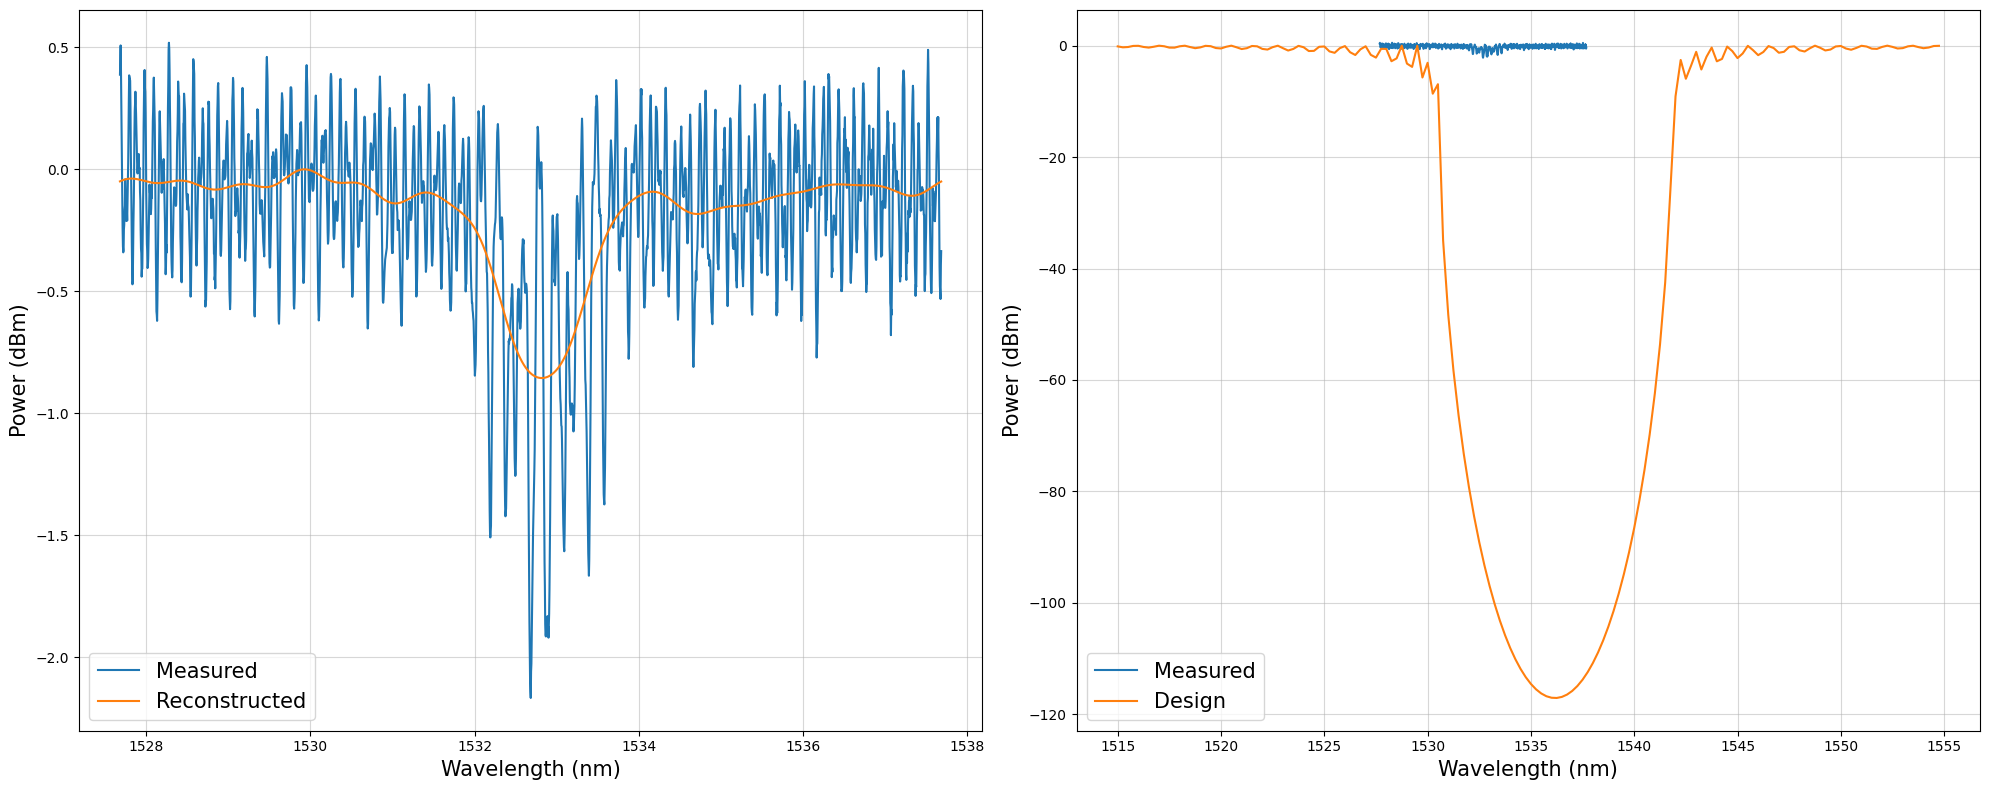

In [17]:
# Measured Minima and Fourier Filtering
wavelength_zoom, power_zoom, power_zoom_ifft = get_resonance(idx, wavelength_dut, power_dut, power_wg, 2*window_size_res, fc)
power_min_real = min(power_zoom)
wl_min_real = wavelength_zoom[np.argmin(power_zoom)]

power_min_ifft = min(power_zoom_ifft)
wl_min_ifft = wavelength_zoom[np.argmin(power_zoom_ifft)]

idx_min, wl_min = find_minima_sides(wavelength_zoom, power_zoom_ifft, distance=2)
bw_measure = np.abs(wl_min[0] - wl_min[1])*1e-9
kappaL_measure = np.arctanh(np.sqrt(1 - 10**(power_min_ifft/10)))

fig, axs = plt.subplots(1, 2, figsize=(20, 8))

#axs[0].scatter(wl_min, power_zoom_ifft[idx_min], label='BW', color='r')
axs[0].plot(wavelength_zoom, power_zoom, label='Measured')
axs[0].plot(wavelength_zoom, power_zoom_ifft, label='Reconstructed')
axs[0].set_xlabel("Wavelength (nm)", fontsize=15)
axs[0].set_ylabel("Power (dBm)", fontsize=15)
axs[0].legend(fontsize=15)
axs[0].grid(which='both', alpha=0.5)

power_min_sim = 10*np.log10(min(T_sim))
wl_min_sim = wavelength_test0[np.argmin(T_sim)]*1e9

idx_min, wl_min = find_minima_sides(wavelength_test0, np.array(T_sim), distance=2)
bw_sim = np.abs(wl_min[0] - wl_min[1])
kappa_sim = np.pi*np.sqrt(((n_avg[i] + delta_n)*bw_sim/((wl_array[i]*1e-9)**2))**2 - 1/(L**2))
kappaL_sim = kappa_sim*L

axs[1].plot(wavelength_zoom, power_zoom, label='Measured')
axs[1].plot(wavelength_test0*1e9, 10*np.log10(np.array(T_sim)), label='Design')
axs[1].set_xlabel("Wavelength (nm)", fontsize=15)
axs[1].set_ylabel("Power (dBm)", fontsize=15)
axs[1].legend(fontsize=15)
axs[1].grid(which='both', alpha=0.5)

plt.tight_layout()
plt.show()

In [18]:
### Scale Factor Optimization ###
tracker = ScaleOptimizationTracker(power_min_ifft, 
    wl_min_ifft, i, z_real, dw_real_p, dw_real_n, M_fab, 
    width_0, wl_min_real, window_size_res, popt_wl, popt_w, delta_n
)

print("--- Optimization Start ---")
t_start_total = time.perf_counter()

res_scale = minimize_scalar(tracker, bounds=bounds_scale, method='bounded', options={'xatol': 1e-4, 'maxiter': MAX_ITER})

t_end_total = time.perf_counter()
optimal_scale = res_scale.x
print("-----------------------------------")
print(f"Total Optimization Time: {t_end_total - t_start_total:.2f} s")
print(f"Optimal Scale Factor: {optimal_scale:.5f}")
print(f"Residual Error Δλ: {np.sqrt(res_scale.fun):.4f} nm")

--- Optimization Start ---
Iteration  1 | Scale Factor (γ): 0.44377 | Δλ: 1.13600 nm | ΔT: 0.38426 dB | Time: 23.859 s
Iteration  2 | Scale Factor (γ): 0.65623 | Δλ: -0.86400 nm | ΔT: 1.59049 dB | Time: 23.153 s
Iteration  3 | Scale Factor (γ): 0.78754 | Δλ: -2.11400 nm | ΔT: 2.42473 dB | Time: 22.949 s
Iteration  4 | Scale Factor (γ): 0.56424 | Δλ: 0.01100 nm | ΔT: 1.03546 dB | Time: 23.402 s
Iteration  5 | Scale Factor (γ): 0.56445 | Δλ: 0.01100 nm | ΔT: 1.03625 dB | Time: 23.305 s
Iteration  6 | Scale Factor (γ): 0.56434 | Δλ: 0.01100 nm | ΔT: 1.03586 dB | Time: 23.400 s
Iteration  7 | Scale Factor (γ): 0.56430 | Δλ: 0.01100 nm | ΔT: 1.03571 dB | Time: 22.798 s
-----------------------------------
Total Optimization Time: 162.87 s
Optimal Scale Factor: 0.56430
Residual Error Δλ: 0.0000 nm


In [19]:
### Sigma Optimization ###
tracker_sigma = SigmaOptimizationTracker(
    power_min_ifft=power_min_ifft,
    wl_min_ifft = wl_min_ifft,
    scale_factor=optimal_scale,
    i=i,
    z_real=z_real,
    dw_real_p=dw_real_p,
    dw_real_n=dw_real_n,
    M_fab=M_fab,
    width_0=width_0,
    wl_min_real=wl_min_ifft,
    window_size=window_size_res,
    popt_wl=popt_wl,
    popt_w=popt_w,
    delta_n=delta_n
)

print("--- Optimization Start ---")
t_start_total = time.perf_counter()

res_sigma = minimize_scalar(tracker_sigma, bounds=bounds_sigma, method='bounded', options={'xatol': 1e-11, 'maxiter': MAX_ITER})

t_end_total = time.perf_counter()
optimal_sigma = res_sigma.x
print("-------------------------------------------")
print(f"Total Optimization Time: {t_end_total - t_start_total:.2f} s")
print(f"Optimal Sigma: {optimal_sigma * 1e9:.3f} nm")
print(f"Residual Error ΔT: {np.sqrt(res_sigma.fun):.4f} dB")

--- Optimization Start ---
Iteration  1 | σ: 126.950 nm | ΔT: 14.24157 dB | Δλ: 0.00000 nm | Time: 21.132 s
Iteration  2 | σ: 193.050 nm | ΔT: 0.06651 dB | Δλ: 0.00000 nm | Time: 20.844 s
Iteration  3 | σ: 233.901 nm | ΔT: -0.79286 dB | Δλ: 0.00000 nm | Time: 24.579 s
Iteration  4 | σ: 213.210 nm | ΔT: -0.59134 dB | Δλ: 0.00000 nm | Time: 23.481 s
Iteration  5 | σ: 167.802 nm | ΔT: 2.59531 dB | Δλ: 0.00000 nm | Time: 23.616 s
Iteration  6 | σ: 183.406 nm | ΔT: 0.72515 dB | Δλ: 0.00000 nm | Time: 23.332 s
Iteration  7 | σ: 199.545 nm | ΔT: -0.22832 dB | Δλ: 0.00000 nm | Time: 23.492 s
Iteration  8 | σ: 191.167 nm | ΔT: 0.17205 dB | Δλ: 0.00000 nm | Time: 23.369 s
Iteration  9 | σ: 194.813 nm | ΔT: -0.02362 dB | Δλ: 0.00000 nm | Time: 23.793 s
Iteration 10 | σ: 194.288 nm | ΔT: 0.00233 dB | Δλ: 0.00000 nm | Time: 22.866 s
-------------------------------------------
Total Optimization Time: 230.51 s
Optimal Sigma: 194.288 nm
Residual Error ΔT: 0.0023 dB


In [20]:
# Initialization
sigma = optimal_sigma
scale_factor = optimal_scale

# TMM Simulation with lithography prediction
t_inicio = time.perf_counter()
dz = L/M_fab

z_real, dw_real_p, dw_real_n = uniform_grating(period_array[i]*1e-6, corrugation, N, duty=0.5, dL=0)
z_edges, dw_mean_p, dw_mean_n = grating_geometry(z_real, dw_real_p, dw_real_n, M_fab)

dw_fab_p, dw_fab_n = prefab_grating(z_real, sigma, dw_real_p, dw_real_n, scale_factor)
z_edges_fab, dw_mean_fab_p, dw_mean_fab_n = grating_geometry(z_real, dw_fab_p, dw_fab_n, M_fab)
w_mean_fab = dw_mean_fab_p - dw_mean_fab_n + width_0

wavelength_test = (np.arange(wl_min_real - window_size_res, wl_min_real + window_size_res, 0.125))*1e-9
M_wl = Bragg_grating_mod(wavelength_test, w_mean_fab, dz, M_fab, popt_wl, popt_w, delta_n)

T_fab = []
phi_r_fab = []
phi_t_fab = []

for j in range(len(wavelength_test)):
    T_fab.append(1/(np.abs(M_wl[j][0, 0])**2))
    phi_r_fab.append(np.angle(1/M_wl[j][0, 0]))
    phi_t_fab.append(np.angle(M_wl[j][1, 0]/M_wl[j][0, 0]))

aux = wavelength_test**2/(2*np.pi*3e8)
tau_r_fab = aux*np.gradient(np.unwrap(np.array(phi_r_fab)), wavelength_test)
tau_t_fab = aux*np.gradient(np.unwrap(np.array(phi_t_fab)), wavelength_test)
phi_r_fab = np.unwrap(phi_r_fab)
phi_t_fab = np.unwrap(phi_t_fab)

t_final = time.perf_counter()
print(f'Execution Time: {t_final - t_inicio:.2f} s')

Execution Time: 30.91 s


### Prediction ###
σ=194.288 nm, γ=0.5643
ΔT = 0.0013 dB
Δλ = 0.0110 nm
MSE = 6.4813e-03


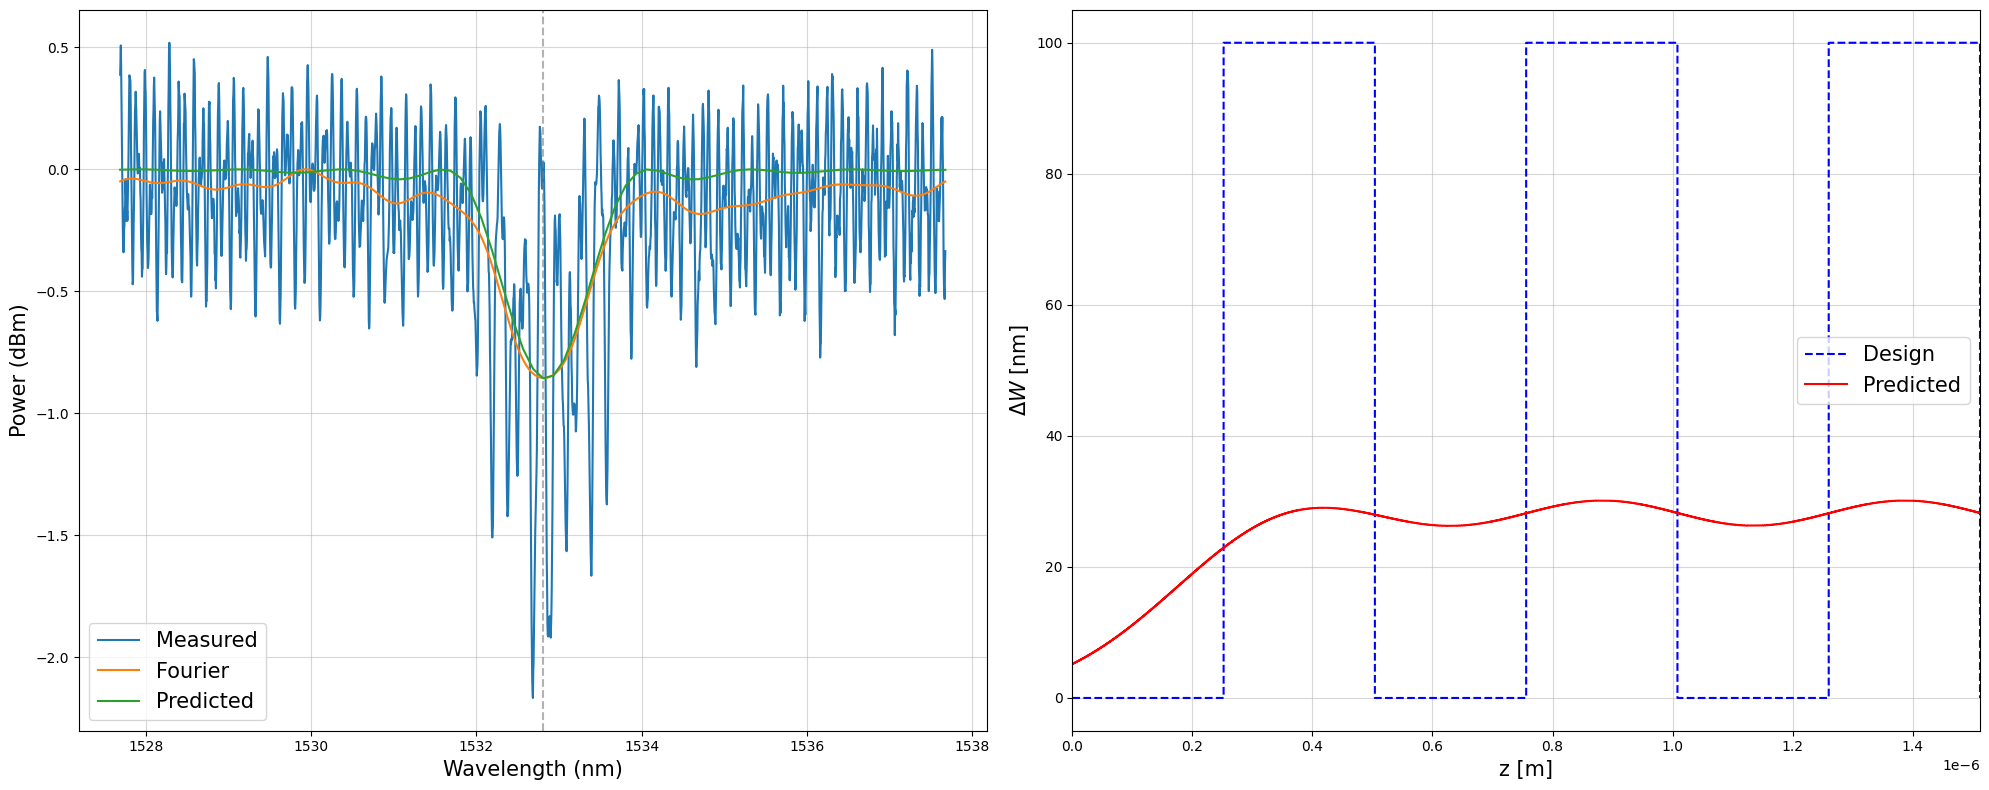

In [21]:
wavelength_test_m = wavelength_test*1e9
T_fab_int = np.interp(wavelength_zoom, wavelength_test_m, T_fab)

power_min_pred = 10*np.log10(min(T_fab))
wl_min_pred = wavelength_test[np.argmin(T_fab)]*1e9
mse = np.mean((power_zoom_ifft - 10*np.log10(T_fab_int))**2)

idx_min, wl_min = find_minima_sides(wavelength_test, T_fab, distance=2)
bw_pred = np.abs(wl_min[0] - wl_min[1])
kappaL_pred = np.arctanh(np.sqrt(1 - 10**(power_min_ifft/10)))

print('### Prediction ###')
print(f'σ={optimal_sigma*1e9:.3f} nm, γ={optimal_scale:.4f}')
print(f'ΔT = {power_min_ifft - power_min_pred:.4f} dB')
print(f'Δλ = {wl_min_ifft - wl_min_pred:.4f} nm')
print(f'MSE = {mse:.4e}')

fig, axs = plt.subplots(1, 2, figsize=(20, 8))

axs[0].plot(wavelength_zoom, power_zoom, label='Measured')
axs[0].plot(wavelength_zoom, power_zoom_ifft, label='Fourier')
axs[0].plot(wavelength_zoom, 10*np.log10(np.array(T_fab_int)), label='Predicted')
axs[0].axvline(wl_min_pred, linestyle='--', color='gray', alpha=0.6)
axs[0].set_xlabel("Wavelength (nm)", fontsize=15)
axs[0].set_ylabel("Power (dBm)", fontsize=15)
axs[0].legend(fontsize=15)
axs[0].grid(which='both', alpha=0.5)

axs[1].step(z_real, dw_real_p*1e3, where='post', label='Design', color='blue', linestyle='--')
axs[1].step(z_real, dw_fab_p*1e3, where='post', label='Predicted', color='red')
#axs[1].bar(z_edges_fab[:-1] + (z_edges_fab[1] - z_edges_fab[0])/2, dw_mean_fab_p + width_0/2, width=(z_edges_fab[1] - z_edges_fab[0]), color='grey', edgecolor='black', label='Discrete')
axs[1].set_xlabel('z [m]', fontsize=15)
axs[1].set_ylabel(r'$\Delta W$ [nm]', fontsize=15)
axs[1].set_xlim(0, 3*period_array_u1[i]*1e-6)
axs[1].legend(fontsize=15)
axs[1].grid(which='both', alpha=0.5)

plt.tight_layout()
plt.show()

In [105]:
print(f'σ={optimal_sigma*1e9:.3f} nm, γ={optimal_scale:.4f}  ')
print(f'λ(adjusted)={wl_min_sim:.2f} nm, λ(measured)={wl_min_real:.2f} nm, λ(ifft)={wl_min_ifft:.2f} nm, λ(pred)={wl_min_pred:.2f} nm  ')
print(f'T(adjusted)={power_min_sim:.3f} dB, T(measured)={power_min_real:.3f} dB, T(ifft)={power_min_ifft:.2f} dB, T(pred)={power_min_pred:.2f} dB  ')
print(f'BW(adjusted)={bw_sim*1e9:.3f} nm, BW(ifft)={bw_measure*1e9:.3f} nm, BW(pred)={bw_pred*1e9:.3f} nm  ')
print(f'κL(adjusted)={kappaL_sim:.3f}, κL(ifft)={kappaL_measure:.3f}, κL(pred)={kappaL_pred:.3f}  ')

σ=188.883 nm, γ=0.4724  
λ(adjusted)=1537.00 nm, λ(measured)=1532.68 nm, λ(ifft)=1532.83 nm, λ(pred)=1532.81 nm  
T(adjusted)=-117.011 dB, T(measured)=-2.148 dB, T(ifft)=-0.85 dB, T(pred)=-0.85 dB  
BW(adjusted)=11.500 nm, BW(ifft)=2.572 nm, BW(pred)=2.500 nm  
κL(adjusted)=11.097, κL(ifft)=0.451, κL(pred)=0.451  


### U1, R2
- __i=7:__   
σ=202.826 nm, γ=0.7452  
λ(adjusted)=1576.50 nm, λ(measured)=1575.11 nm, λ(ifft)=1575.02 nm, λ(pred)=1574.98 nm  
T(adjusted)=-205.587 dB, T(measured)=-5.008 dB, T(ifft)=-3.42 dB, T(pred)=-3.43 dB  
BW(adjusted)=20.750 nm, BW(ifft)=3.008 nm, BW(pred)=2.750 nm  
κL(adjusted)=20.041, κL(ifft)=0.947, κL(pred)=0.947   
  
- __i=6:__  
σ=201.156 nm, γ=0.7278  
λ(adjusted)=1566.75 nm, λ(measured)=1564.51 nm, λ(ifft)=1564.60 nm, λ(pred)=1564.63 nm  
T(adjusted)=-186.648 dB, T(measured)=-3.856 dB, T(ifft)=-2.78 dB, T(pred)=-2.79 dB  
BW(adjusted)=18.500 nm, BW(ifft)=2.968 nm, BW(pred)=2.625 nm  
κL(adjusted)=17.928, κL(ifft)=0.844, κL(pred)=0.844  
  
- __i=5:__  
σ=198.631 nm, γ=0.6807  
λ(adjusted)=1556.75 nm, λ(measured)=1554.18 nm, λ(ifft)=1554.01 nm, λ(pred)=1554.06 nm  
T(adjusted)=-165.577 dB, T(measured)=-3.772 dB, T(ifft)=-2.12 dB, T(pred)=-2.12 dB  
BW(adjusted)=17.250 nm, BW(ifft)=2.864 nm, BW(pred)=2.500 nm  
κL(adjusted)=16.788, κL(ifft)=0.727, κL(pred)=0.727 

- __i=4:__  
σ=198.350 nm, γ=0.6078  
λ(adjusted)=1547.00 nm, λ(measured)=1543.19 nm, λ(ifft)=1543.49 nm, λ(pred)=1543.57 nm  
T(adjusted)=-142.346 dB, T(measured)=-2.989 dB, T(ifft)=-1.26 dB, T(pred)=-1.22 dB  
BW(adjusted)=14.250 nm, BW(ifft)=2.944 nm, BW(pred)=2.625 nm  
κL(adjusted)=13.847, κL(ifft)=0.552, κL(pred)=0.552  
  
- __i=3:__  
σ=188.883 nm, γ=0.4724  
λ(adjusted)=1537.00 nm, λ(measured)=1532.68 nm, λ(ifft)=1532.83 nm, λ(pred)=1532.81 nm  
T(adjusted)=-117.011 dB, T(measured)=-2.148 dB, T(ifft)=-0.85 dB, T(pred)=-0.85 dB  
BW(adjusted)=11.500 nm, BW(ifft)=2.572 nm, BW(pred)=2.500 nm  
κL(adjusted)=11.097, κL(ifft)=0.451, κL(pred)=0.451  